# HW 6 m4 cluster with DNN

Demonstrate the use of a densely connected neural network, like the one we trained on the MNIST data set, for classifying stars in the M4 cluster using Gaia's measurements of stars' locations on the sky (right ascension and declination).  This is basically a repeat of what we covered in class, but this time I want you to even out the training set to include roughly equal numbers of M4 members and non-members.

In [1]:
import numpy as np

import jax
import jax.numpy as jnp

import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from flax import linen as nn

In [2]:
# import data 
m4_df = pd.read_fwf('../../../data/NGC6121-1.dat', names=['source_id', 'ra', 'dec', 'phot_g_mean_mag'])
m4_df

,source_id,ra,dec,phot_g_mean_mag
0,6045504229661220736,245.99162,-26.34434,18.438
1,6045504981264184192,246.03035,-26.28057,18.769
2,6045508902585952640,245.88761,-26.24297,19.072
3,6045507180287440000,245.85343,-26.28453,18.495
4,6045503473747038464,245.87124,-26.34628,17.163
...,...,...,...,...
19503,6045337962873610240,245.13976,-27.09970,19.705
19504,6045298891556291712,245.48339,-27.19208,19.493
19505,6045305866578950784,245.69445,-27.06942,18.290
19506,6045303774938119808,245.80824,-27.07275,19.267


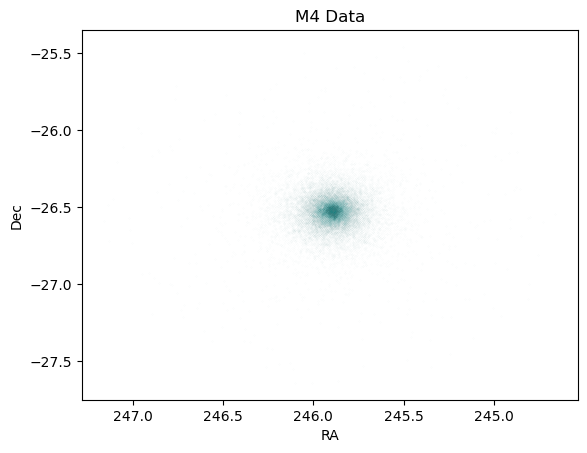

In [3]:
plt.scatter(m4_df.ra, m4_df.dec, s=0.0001, color='teal')
plt.title('M4 Data')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()

In [4]:
df = pd.read_csv('../../../../hub_data_share/m4_gaia_source.csv')
df.head()

,designation,source_id,ra,dec,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,...,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,bp_rp,radial_velocity,radial_velocity_error
0,Gaia DR3 6048466004733106048,6048466004733106048,244.500044,-26.152984,2.274643,1.125653,2.020732,8.490148,-7.892926,1.880442,...,110.199646,20.722200,4.511861,21.159956,17.483234,19.606243,1.661088,1.553713,NaN,NaN
1,Gaia DR3 6048666665606296064,6048666665606296064,244.500060,-25.906141,0.632528,0.769472,0.822029,2.582879,-0.097646,0.931963,...,178.075440,20.311983,10.519053,21.239437,20.069353,19.297583,1.380115,1.941855,NaN,NaN
2,Gaia DR3 6048358561832132864,6048358561832132864,244.500066,-26.918531,1.153917,0.907036,1.272184,7.455110,-5.327529,1.236975,...,152.003370,20.567377,7.892730,21.225716,16.701073,19.618095,1.404567,1.607620,NaN,NaN
3,Gaia DR3 6048842759265408128,6048842759265408128,244.500077,-25.216618,NaN,NaN,NaN,NaN,NaN,NaN,...,68.553120,20.875511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Gaia DR3 6048837635368203648,6048837635368203648,244.500085,-25.318745,0.405547,0.118409,3.424970,1.204035,-0.644142,0.158066,...,959.558700,17.849728,73.395320,18.590256,129.001560,16.973124,1.310396,1.617132,NaN,NaN


In [5]:
df.columns

Index(['designation', 'source_id', 'ra', 'dec', 'parallax', 'parallax_error',
       'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'astrometric_n_good_obs_al', 'astrometric_chi2_al',
       'visibility_periods_used', 'phot_g_mean_flux_over_error',
       'phot_g_mean_mag', 'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag',
       'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'radial_velocity',
       'radial_velocity_error'],
      dtype='object')

that's a lot!

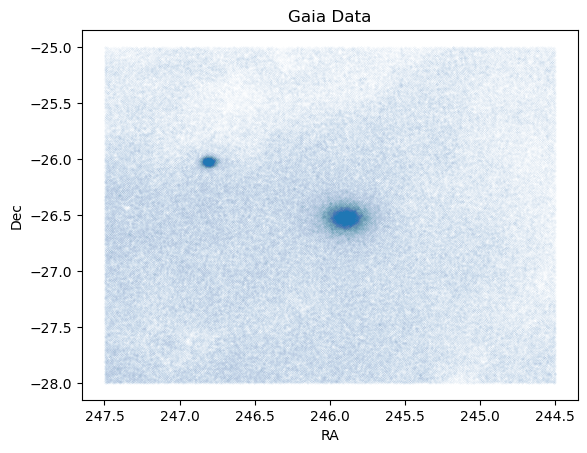

In [6]:
plt.scatter(df.ra, df.dec, s=0.0001)
plt.gca().invert_xaxis()
plt.title('Gaia Data')
plt.xlabel('RA')
plt.ylabel('Dec');

## 1) Cross-Matching between two data sets

In [7]:
m4_sel = df['source_id'].isin(m4_df.source_id)
print(np.count_nonzero(m4_sel))
print(np.count_nonzero(~m4_sel))

19084
475912


In [8]:
df.shape

(494996, 25)

In [9]:
m4_df.shape

(19508, 4)

In [10]:
m4_sel.shape

(494996,)

pink is not a member, purple is a member


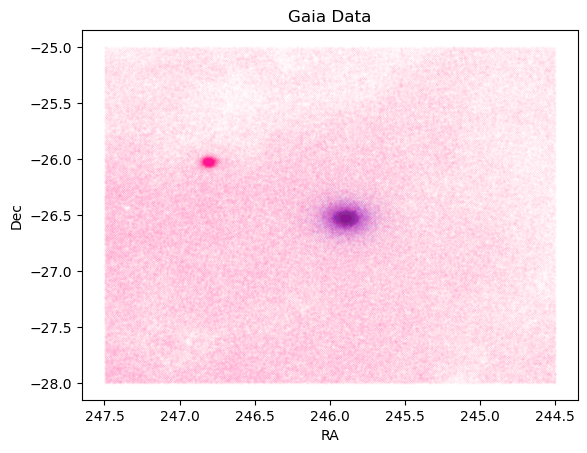

In [11]:
print('pink is not a member, purple is a member')
plt.scatter(df.ra[~m4_sel], df.dec[~m4_sel], s=0.0001, color='deeppink')
plt.scatter(df.ra[m4_sel], df.dec[m4_sel], s=0.0001, color='blueviolet')
plt.gca().invert_xaxis()
plt.title('Gaia Data')
plt.xlabel('RA')
plt.ylabel('Dec');

In [12]:
# create a df of just RA and Dec
# this is defining RA and Dec as our features
params = ['ra', 'dec']
X = np.array(df[params])


# classify M4 membership as in (1) or out (0)
y = m4_sel.astype(int)

print(f'X.shape: {X.shape}\ny.shape: {y.shape}')

X.shape: (494996, 2)
y.shape: (494996,)


In [13]:
# create a df of just RA and Dec
# this is defining RA and Dec as our features
params = ['ra', 'dec']
X = np.array(df[params])


# classify M4 membership as in (1) or out (0)
y = m4_sel.astype(int)

# remove rows with missing values of RA or Dec
nans = np.any(np.isnan(X), axis=1)
X = X[~nans]
y = y[~nans]

# make masks for each class to split the rows into members and nonmebers
m4_mask = y == 1
non_mask = y == 0

# split feature arrays by class
X_m4 = np.array(X[m4_mask]) # all features for M4 stars
y_m4 = np.array(y[m4_mask]) # all features for non-M4 stars
X_non = np.array(X[non_mask]) # corresponding labels
y_non = np.array(y[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)
X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))
print(f'X.shape: {X.shape}\ny.shape: {y.shape}')


X.shape: (38168, 2)
y.shape: (38168,)


In [14]:
from sklearn.model_selection import train_test_split
# hannah said to do this and I beleive her
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.fit_transform(X_tst)

# make some arrays
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

# Data batching!!
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

### Time for model training

a lot of this is copy and paste from the DNN construction from DNN Classifiers lecture

In [17]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

dummy_input = jnp.ones((1, 2))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,2]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,2]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[2,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 30 (120 B)       │
├─────────┼────────────────

In [18]:
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

In [19]:
from clu import metrics
from flax.training import train_state
from flax import struct
import optax

In [20]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [21]:
n_epochs = 50

step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1
  

train epoch: 1, loss: 0.21469803154468536, accuracy: 92.96583557128906
test epoch: 1, loss: 0.21107394993305206, accuracy: 92.7691879272461
train epoch: 2, loss: 0.20095932483673096, accuracy: 93.24276733398438
test epoch: 2, loss: 0.20882345736026764, accuracy: 92.74298858642578
train epoch: 3, loss: 0.20012718439102173, accuracy: 93.22528076171875
test epoch: 3, loss: 0.20646177232265472, accuracy: 92.95257568359375
train epoch: 4, loss: 0.1995677798986435, accuracy: 93.25151062011719
test epoch: 4, loss: 0.20607870817184448, accuracy: 92.9787826538086
train epoch: 5, loss: 0.1994996815919876, accuracy: 93.24568176269531
test epoch: 5, loss: 0.20547951757907867, accuracy: 93.00497436523438
train epoch: 6, loss: 0.19937892258167267, accuracy: 93.26900482177734
test epoch: 6, loss: 0.20519901812076569, accuracy: 92.9787826538086
train epoch: 7, loss: 0.19935405254364014, accuracy: 93.28067016601562
test epoch: 7, loss: 0.20513978600502014, accuracy: 93.00497436523438
train epoch: 8, lo

In [22]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.933
Mean testing accuracy: 0.930


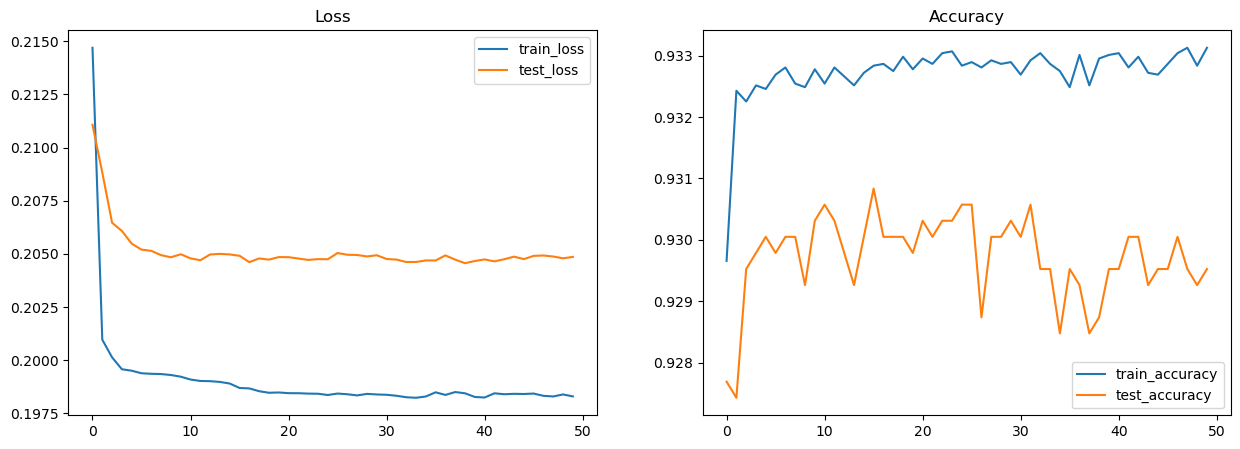

<Figure size 640x480 with 0 Axes>

In [23]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.set_title('Loss')
ax2.set_title('Accuracy')
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss')
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy')
ax1.legend()
ax2.legend()
plt.show()
plt.clf();

In [24]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([1, 1, 1, ..., 0, 1, 0], dtype=int32)

(array([1792.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2025.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

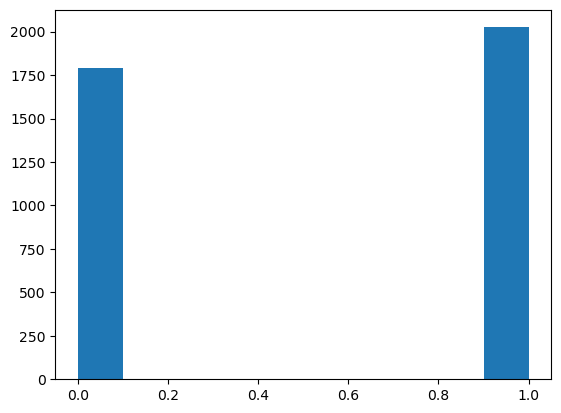

In [25]:
plt.hist(pred)

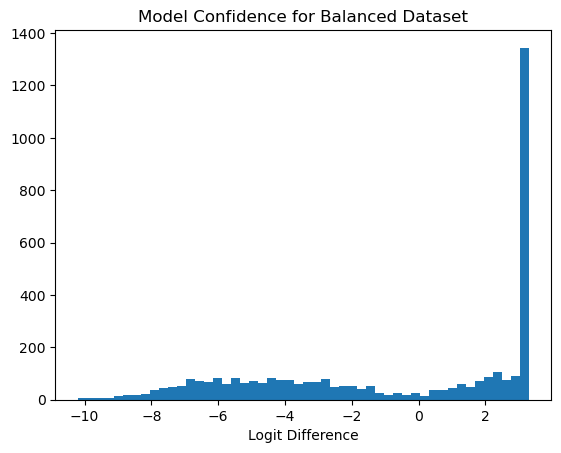

In [26]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), bins=50)
plt.title('Model Confidence for Balanced Dataset')
plt.xlabel('Logit Difference');

In [27]:
ra_full = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()
ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]
dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]
ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))
print(ra.shape, dec.shape)

(38168,) (38168,)


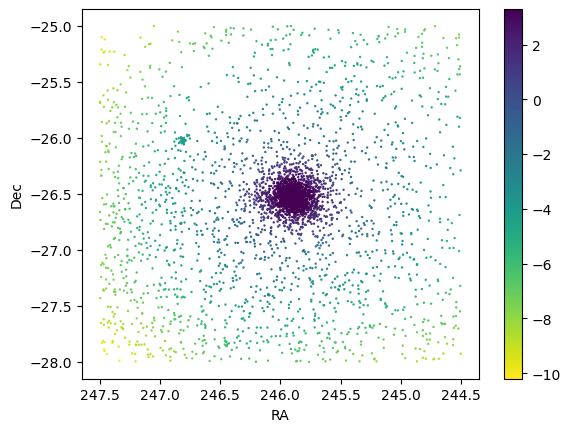

In [28]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

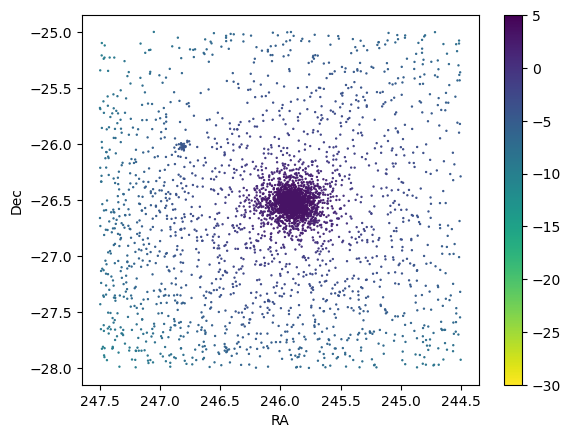

In [29]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

## Questions

1. What training and validation accuracies are you able to achieve?

2. Is your trained model confident that any of the stars in your test set are part of M4?

3. What did your model learn?  Can you come up with a useful way to probe your model and visualize the results to answer this question?

4. Do you think more sophisticated models could do better with this classification task using only sky positions?  Use the properties of the training set to make your argument.

## Extra Work for Grads ;P

Make use of other features observed by Gaia to improve your classifier.  Be sure to use the data model documentation to understand what each feature is, and **explain why you think it would be useful for identifying cluster members.**  What training and validation accuracies can you achieve?  Does your trained model find any stars it believes are confidently in M4 that weren't in the M4 catalog?

In [30]:
# much of the bulk of the code is the same
# we start by updating our features

# this is defining RA and Dec as our features
params = ['ra', 'dec', 'pmra', 'pmdec']
X = np.array(df[params])


# classify M4 membership as in (1) or out (0)
y = m4_sel.astype(int)

# remove rows with missing values of RA or Dec
nans = np.any(np.isnan(X), axis=1)
X = X[~nans]
y = y[~nans]

# make masks for each class to split the rows into members and nonmebers
m4_mask = y == 1
non_mask = y == 0

# split feature arrays by class
X_m4 = np.array(X[m4_mask]) # all features for M4 stars
y_m4 = np.array(y[m4_mask]) # all features for non-M4 stars
X_non = np.array(X[non_mask]) # corresponding labels
y_non = np.array(y[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)
X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))
print(f'X.shape: {X.shape}\ny.shape: {y.shape}')

X.shape: (38038, 4)
y.shape: (38038,)


In [31]:
from sklearn.model_selection import train_test_split
# hannah said to do this and I beleive her
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [32]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.fit_transform(X_tst)

# make some arrays
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

# Data batching!!
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((534, 64, 4), (534, 64))

In [33]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

dummy_input = jnp.ones((1, 4))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,4]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,4]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[4,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 50 (200 B)       │
├─────────┼────────────────

In [34]:
X_train.shape, y_train.shape

((534, 64, 4), (534, 64))

In [35]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [36]:
n_epochs = 50

step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1
  

train epoch: 1, loss: 0.06868011504411697, accuracy: 98.46090698242188
test epoch: 1, loss: 0.059725143015384674, accuracy: 98.60672760009766
train epoch: 2, loss: 0.05115674436092377, accuracy: 98.7505874633789
test epoch: 2, loss: 0.05623851343989372, accuracy: 98.65930938720703
train epoch: 3, loss: 0.04909577593207359, accuracy: 98.8091049194336
test epoch: 3, loss: 0.05184435099363327, accuracy: 98.73816680908203
train epoch: 4, loss: 0.04836083948612213, accuracy: 98.80032348632812
test epoch: 4, loss: 0.051083870232105255, accuracy: 98.73816680908203
train epoch: 5, loss: 0.047973163425922394, accuracy: 98.8091049194336
test epoch: 5, loss: 0.05186134949326515, accuracy: 98.68559265136719
train epoch: 6, loss: 0.04775610566139221, accuracy: 98.82958221435547
test epoch: 6, loss: 0.05021430552005768, accuracy: 98.71188354492188
train epoch: 7, loss: 0.0475928969681263, accuracy: 98.82373809814453
test epoch: 7, loss: 0.05045231431722641, accuracy: 98.71188354492188
train epoch: 8

In [37]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.989
Mean testing accuracy: 0.987


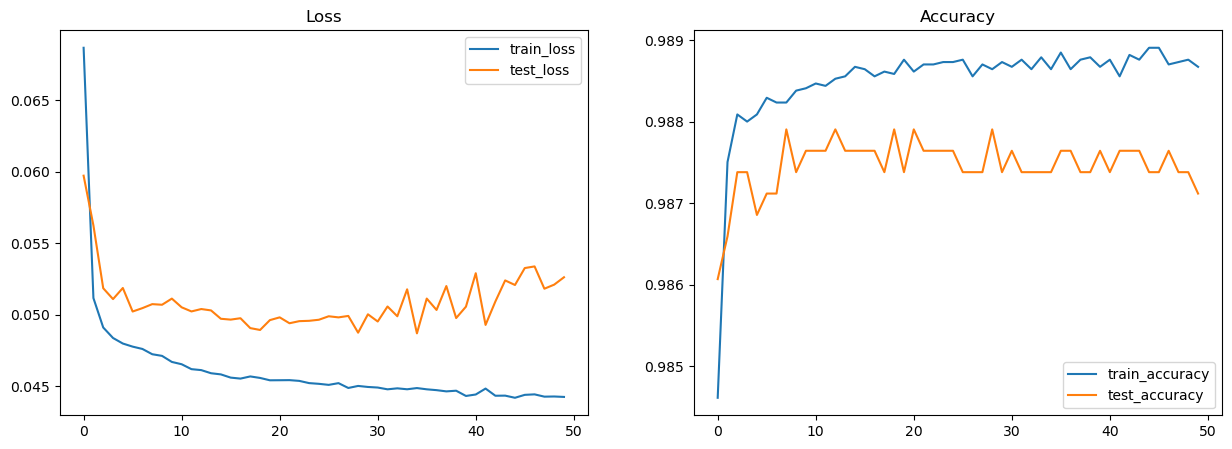

<Figure size 640x480 with 0 Axes>

In [38]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.set_title('Loss')
ax2.set_title('Accuracy')
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss')
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy')
ax1.legend()
ax2.legend()
plt.show()
plt.clf();

In [39]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, ..., 1, 1, 0], dtype=int32)

(array([1863.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1941.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

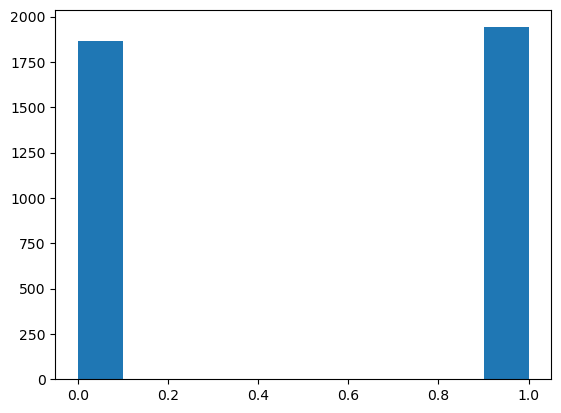

In [40]:
plt.hist(pred)

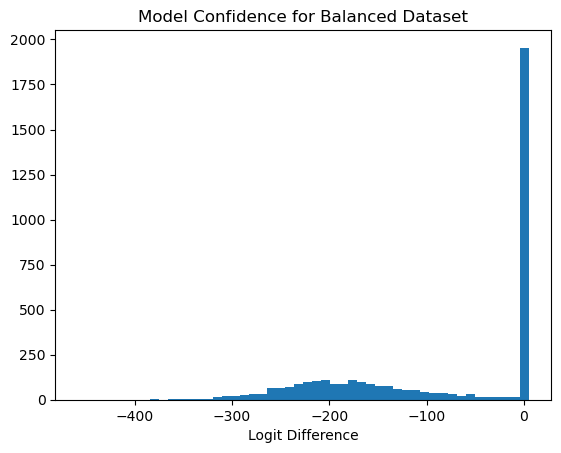

In [41]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), bins=50)
plt.title('Model Confidence for Balanced Dataset')
plt.xlabel('Logit Difference');

In [42]:
ra_full = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()
ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]
dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]
ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))
print(ra.shape, dec.shape)

(38038,) (38038,)


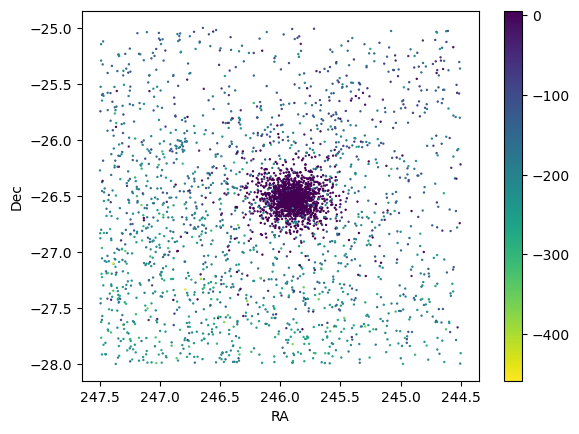

In [43]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()

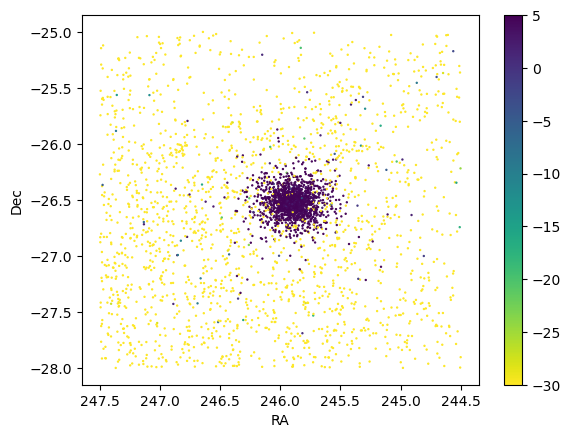

In [44]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar()
